# Study Partner Compatibility Prediction model

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [21]:
np.random.seed(42)

n = 300

data = {
    'User1_Hours': np.random.randint(1, 10, n),
    'User2_Hours': np.random.randint(1, 10, n),
    'User1_Focus': np.random.randint(1, 10, n),
    'User2_Focus': np.random.randint(1, 10, n),
    'Common_Subjects': np.random.randint(0, 6, n),
}

df = pd.DataFrame(data)

df['Compatible'] = (
    (abs(df['User1_Hours'] - df['User2_Hours']) <= 3) &
    (abs(df['User1_Focus'] - df['User2_Focus']) <= 3) &
    (df['Common_Subjects'] >= 2)
).astype(int)

df.head()

,User1_Hours,User2_Hours,User1_Focus,User2_Focus,Common_Subjects,Compatible
0,7,1,1,8,2,0
1,4,8,3,1,1,0
2,8,1,4,9,1,0
3,5,9,1,6,5,0
4,7,6,1,3,2,1


In [22]:
df['Compatible'].value_counts()

Compatible
0    213
1     87
Name: count, dtype: int64

In [23]:
X = df.drop('Compatible', axis=1)
y = df['Compatible']

In [24]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=42, stratify=y
)

In [26]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)
model.fit(X_train_scaled, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [28]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Adjust threshold
threshold = 0.4
y_pred = (y_prob > threshold).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8833333333333333

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.91      0.92        43
           1       0.78      0.82      0.80        17

    accuracy                           0.88        60
   macro avg       0.85      0.87      0.86        60
weighted avg       0.89      0.88      0.88        60



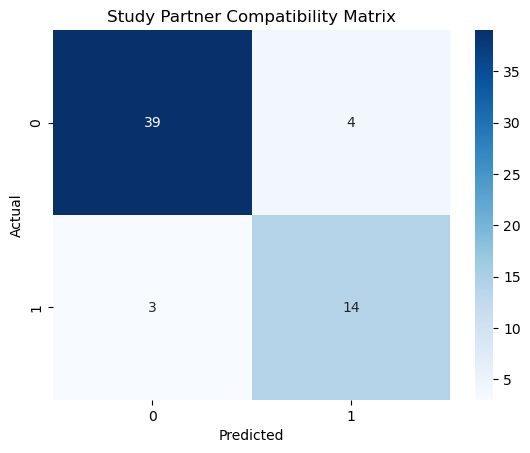

In [29]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Study Partner Compatibility Matrix")
plt.show()

In [30]:
feature_names = poly.get_feature_names_out(X.columns)

importances = model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

importance_df.head(10)

,Feature,Importance
16,User1_Focus Common_Subjects,0.104640
18,User2_Focus Common_Subjects,0.081753
19,Common_Subjects^2,0.079366
4,Common_Subjects,0.074044
9,User1_Hours Common_Subjects,0.061114
8,User1_Hours User2_Focus,0.060339
13,User2_Hours Common_Subjects,0.059604
15,User1_Focus User2_Focus,0.054602
12,User2_Hours User2_Focus,0.049258
11,User2_Hours User1_Focus,0.048105


In [31]:
sample = np.array([[6, 7, 7, 6, 4]])

sample_poly = poly.transform(sample)
sample_scaled = scaler.transform(sample_poly)

prediction = model.predict(sample_scaled)
prob = model.predict_proba(sample_scaled)

print("Prediction:", "Compatible" if prediction[0] == 1 else "Not Compatible")
print("Confidence:", prob)

Prediction: Compatible
Confidence: [[0.225 0.775]]


C:\Users\POOJA D KOTKAR\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
